# Simple LSTM

## 事前準備

In [1]:
import torch

# GPUが使えるか確認してデバイスを設定
# NOTE: `x = x.to(device) ` とすることで対象のデバイスに切り替え可能
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from typing import Callable

import random
import torch
import numpy as np


# シード値の固定
# NOTE: 戻り値はDataLoaderのシード固定に使用する。　
# 　　　　　　　　　　　　(ex) loader = DataLoader(..., worker_init_fn=seed_worker, generator=generator)
def fixing_seed(seed: int=42) -> tuple[torch.Generator, Callable]:
    # Python のシード固定
    random.seed(seed)
    # Numpy のシード固定
    np.random.seed(seed)
    # PyTorch のシード固定
    torch.manual_seed(seed)
    # CUDA の再現性確保の設定
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # DataLoader 各ワーカー用の初期化関数
    def seed_worker_fn(worker_id: int) -> None:
        # 各 worker で Python / NumPy も固定
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    # DataLoader の乱数源
    generator = torch.Generator()
    generator.manual_seed(seed)

    return generator, seed_worker_fn

In [3]:
SEED = 24

torch_generator, seed_worker_fn = fixing_seed(SEED)

## LSTM

In [4]:
import math
import torch
import torchinfo
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

### 訓練データ用意(sinカーブ)

sinカーブに乱数ノイズを加えたものを時系列データとし、訓練に使用する

In [5]:
sin_x = torch.linspace(-2 * math.pi, 2 * math.pi, 100)
sin_y = torch.sin(sin_x) + 0.1 * torch.randn(len(sin_x))

### データ前処理

10個の値を入力データとし、その一つ後ろのデータを正解データとする

In [6]:
N_TIME = 10                     # 時系列データ幅
N_SAMPLE = len(sin_x) - N_TIME  # サンプル数

input_data = torch.zeros((N_SAMPLE, N_TIME, 1))
target_data = torch.zeros((N_SAMPLE, 1))

for i in range(N_SAMPLE):
    input_data[i] = sin_y[i:i + N_TIME].view(-1, 1)         # 入力データ：(時刻の数, 入力の数)
    target_data[i] = sin_y[i + N_TIME:i + N_TIME + 1]       # 正解データ：入力データの一つ後ろのデータ

### DataLoader作成

In [7]:
BATCH_SIZE = 8

dataset = TensorDataset(input_data, target_data)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch_generator, worker_init_fn=seed_worker_fn)

### モデル構築

In [8]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.LSTM(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y_rnn, (h, c) = self.rnn(x, None)   # h:中間層の最終時刻の値、c:記憶セル
        y = self.fc(y_rnn[:, -1, :])        # -1で最後の時刻のみ取得し、全結合層に渡す
        return y

In [9]:
model = Network()
model = model.to(device)

In [10]:
torchinfo.summary(model, input_size=(8, 10, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Network                                  [8, 1]                    --
├─LSTM: 1-1                              [8, 10, 64]               17,152
├─Linear: 1-2                            [8, 1]                    65
Total params: 17,217
Trainable params: 17,217
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.37
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.07
Estimated Total Size (MB): 0.11

### 学習

#### ハイパーパラメータ

In [11]:
LR = 0.01
N_EPOCHS = 100

VERBOSE = 10

#### 学習処理

  0%|          | 0/100 [00:00<?, ?it/s]

epoch: 1, train_loss: 0.2997


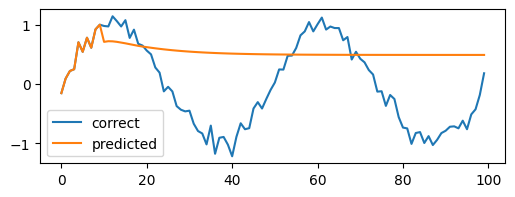

epoch: 11, train_loss: 0.0204


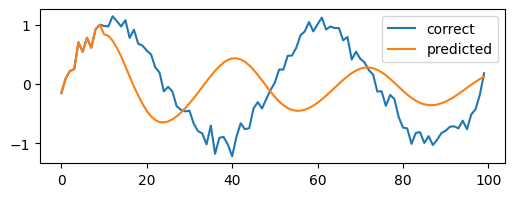

epoch: 21, train_loss: 0.0212


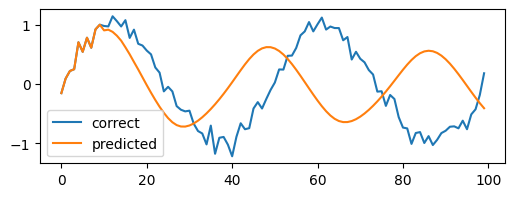

epoch: 31, train_loss: 0.0280


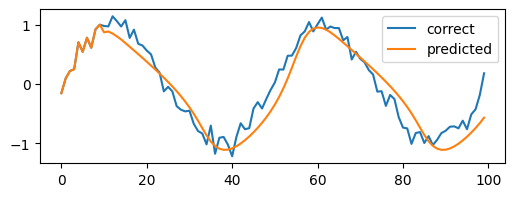

epoch: 41, train_loss: 0.0195


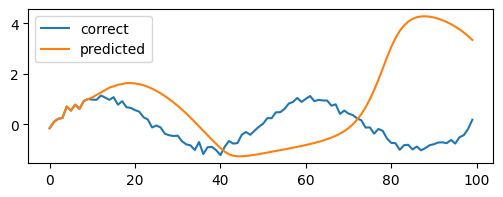

epoch: 51, train_loss: 0.0223


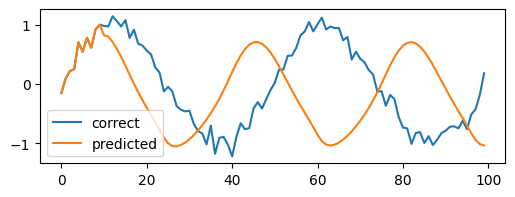

epoch: 61, train_loss: 0.0211


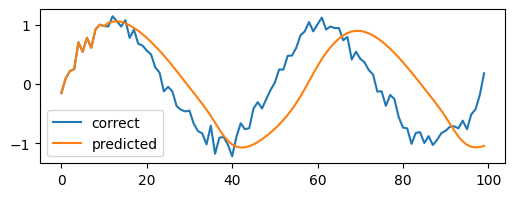

epoch: 71, train_loss: 0.0178


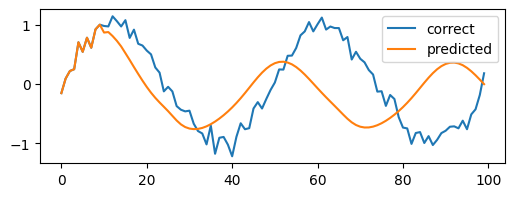

epoch: 81, train_loss: 0.0159


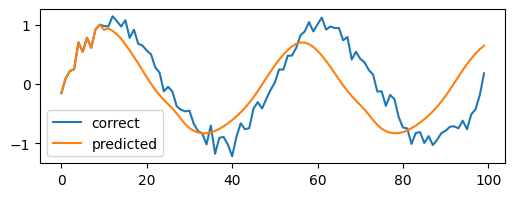

epoch: 91, train_loss: 0.0245


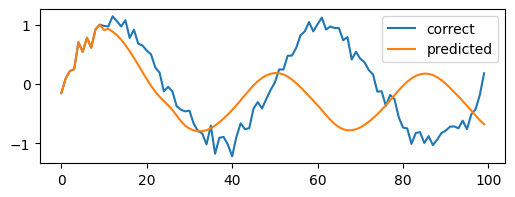

epoch: 100, train_loss: 0.0173


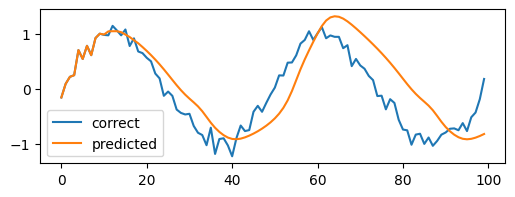

In [12]:
loss_func = nn.MSELoss()

# SGDだとうまく収束しなかったのでAdamに差し替え
# optimizer = optim.SGD(model.parameters(), lr=LR)
optimizer = optim.Adam(model.parameters(), lr=LR)

record_train_loss = []



def verbose_process(epoch: int, train_loss: float) -> None:
    global model, input_data
    # 進捗表示
    print(f'epoch: {epoch + 1}, train_loss: {train_loss:.4f}')

    # 予測を実施
    model.eval()
    predicted = list(input_data[0].view(-1))    # 最初の入力

    for i in range(N_SAMPLE):
        x = torch.tensor(predicted[-N_TIME:])   # 直近の時系列を取り出す
        x = x.view(1, N_TIME, 1)                # 変形:(バッチサイズ、時刻の数、入力の数)
        y = model(x.to(device))
        predicted.append(y[0].item())           # 予測結果を格納

    # 予測結果の描画
    plt.figure(figsize=(6, 2))
    plt.plot(range(len(sin_y)), sin_y, label="correct")
    plt.plot(range(len(predicted)), predicted, label="predicted")
    plt.legend()
    plt.show()


for epoch in tqdm(range(N_EPOCHS)):
    model.train()
    train_loss = 0

    for j, (x, t) in enumerate(train_loader):
        x, t = x.to(device), t.to(device)
        y = model(x)
        loss = loss_func(y, t)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)
    record_train_loss.append(train_loss)

    if epoch % VERBOSE == 0 or epoch == N_EPOCHS - 1:
        verbose_process(epoch, train_loss)

### 評価

#### 誤差の推移

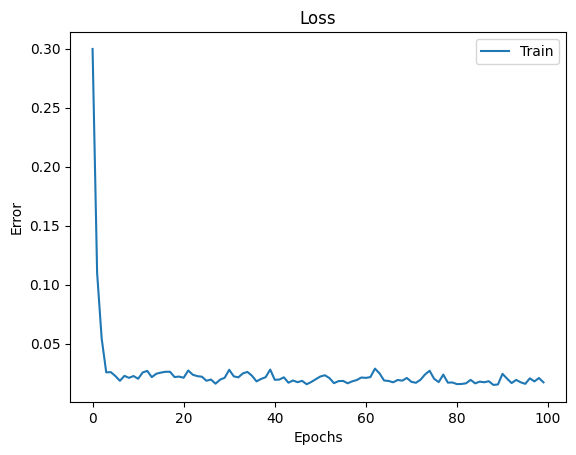

In [13]:
plt.plot(range(len(record_train_loss)), record_train_loss, label='Train')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()